In [7]:
import re
import pandas as pd

In [8]:
f = open('WhatsApp Chat with HariSundar.txt','r',encoding='utf-8')

In [9]:
data =f.read()

In [10]:
print(data)

01/09/23, 10:08 pm - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.
04/09/23, 7:22 pm - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.
06/09/23, 5:17 pm - A.M.MUKILAN: Hi da I am mukilan from AIML Batch A
Can you send me the notes taken today
06/09/23, 5:57 pm - HariSundar: yeh bro just 2 mins
06/09/23, 5:58 pm - HariSundar: why didn't you come to clg today??
06/09/23, 5:58 pm - A.M.MUKILAN: K thanks bro
06/09/23, 5:58 pm - HariSundar: Bunk 👀
06/09/23, 5:58 pm - HariSundar: ??
06/09/23, 5:58 pm - A.M.MUKILAN: Health issues bro
06/09/23, 5:58 pm - HariSundar: ohh okay bro
06/09/23, 5:58 pm - HariSundar: take care buddy
06/09/23, 5:58 pm - HariSundar: how are you now?
06/09/23, 5:58 pm - A.M.MUKILAN: Illa bro
06/09/23, 5:58 pm - HariSundar: fine??
06/09/23, 5:58 pm - A.M.MUKILAN: K bro
06/09/23, 5:58 pm - HariSundar: okay okay 😂
06/09/23, 5:58 pm -

In [11]:
print(type(data))

<class 'str'>


In [12]:
import pandas as pd
import re

# Read the full text from a file (or paste your chat)
with open('WhatsApp Chat with HariSundar.txt', encoding='utf-8') as file:
    chat_text = file.read()

# Split into lines
lines = chat_text.strip().split('\n')

# WhatsApp correct pattern - robust for different formats
pattern = r'^(\d{1,2}/\d{1,2}/\d{2,4}), (\d{1,2}:\d{2})\s?(am|pm|AM|PM|[ap]m)?\s-\s(.*)'

dates = []
messages = []

for line in lines:
    match = re.match(pattern, line)
    if match:
        date = match.group(1)
        time = match.group(2)
        ampm = match.group(3) or ''  # Sometimes missing
        message = match.group(4)

        full_datetime = f"{date}, {time} {ampm}".strip()
        dates.append(full_datetime)
        messages.append(message)
    else:
        if messages:
            messages[-1] += ' ' + line  # continuation line (multi-line message)

# Create DataFrame
df = pd.DataFrame({'datetime': dates, 'user_message': messages})

# Try parsing the datetime properly
def try_parsing_datetime(text):
    for fmt in ('%d/%m/%y, %I:%M %p', '%d/%m/%Y, %I:%M %p', '%d/%m/%y, %H:%M', '%d/%m/%Y, %H:%M'):
        try:
            return pd.to_datetime(text, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df['datetime'] = df['datetime'].apply(try_parsing_datetime)

# Drop rows where datetime parsing completely failed (like system messages)
df = df.dropna(subset=['datetime'])

# Reset index
df = df.reset_index(drop=True)

print(df.head(10))


             datetime                                       user_message
0 2023-09-01 22:08:00  Messages and calls are end-to-end encrypted. O...
1 2023-09-04 19:22:00  Messages and calls are end-to-end encrypted. O...
2 2023-09-06 17:17:00  A.M.MUKILAN: Hi da I am mukilan from AIML Batc...
3 2023-09-06 17:57:00                    HariSundar: yeh bro just 2 mins
4 2023-09-06 17:58:00     HariSundar: why didn't you come to clg today??
5 2023-09-06 17:58:00                          A.M.MUKILAN: K thanks bro
6 2023-09-06 17:58:00                                 HariSundar: Bunk 👀
7 2023-09-06 17:58:00                                     HariSundar: ??
8 2023-09-06 17:58:00                     A.M.MUKILAN: Health issues bro
9 2023-09-06 17:58:00                           HariSundar: ohh okay bro


In [13]:
dates

['01/09/23, 10:08 pm',
 '04/09/23, 7:22 pm',
 '06/09/23, 5:17 pm',
 '06/09/23, 5:57 pm',
 '06/09/23, 5:58 pm',
 '06/09/23, 5:58 pm',
 '06/09/23, 5:58 pm',
 '06/09/23, 5:58 pm',
 '06/09/23, 5:58 pm',
 '06/09/23, 5:58 pm',
 '06/09/23, 5:58 pm',
 '06/09/23, 5:58 pm',
 '06/09/23, 5:58 pm',
 '06/09/23, 5:58 pm',
 '06/09/23, 5:58 pm',
 '06/09/23, 5:58 pm',
 '06/09/23, 5:58 pm',
 '06/09/23, 5:59 pm',
 '06/09/23, 5:59 pm',
 '06/09/23, 6:23 pm',
 '06/09/23, 6:23 pm',
 '06/09/23, 6:28 pm',
 '06/09/23, 6:28 pm',
 '06/09/23, 6:28 pm',
 '06/09/23, 6:28 pm',
 '06/09/23, 6:29 pm',
 '06/09/23, 6:30 pm',
 '06/09/23, 6:30 pm',
 '06/09/23, 6:30 pm',
 '06/09/23, 6:30 pm',
 '06/09/23, 6:30 pm',
 '06/09/23, 6:30 pm',
 '06/09/23, 6:30 pm',
 '06/09/23, 6:31 pm',
 '06/09/23, 6:31 pm',
 '06/09/23, 6:31 pm',
 '06/09/23, 6:31 pm',
 '06/09/23, 6:32 pm',
 '06/09/23, 6:32 pm',
 '06/09/23, 6:32 pm',
 '06/09/23, 6:32 pm',
 '06/09/23, 6:33 pm',
 '06/09/23, 6:33 pm',
 '06/09/23, 6:33 pm',
 '06/09/23, 6:34 pm',
 '06/09/2

In [14]:
messages

['Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.',
 'Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.',
 'A.M.MUKILAN: Hi da I am mukilan from AIML Batch A Can you send me the notes taken today',
 'HariSundar: yeh bro just 2 mins',
 "HariSundar: why didn't you come to clg today??",
 'A.M.MUKILAN: K thanks bro',
 'HariSundar: Bunk 👀',
 'HariSundar: ??',
 'A.M.MUKILAN: Health issues bro',
 'HariSundar: ohh okay bro',
 'HariSundar: take care buddy',
 'HariSundar: how are you now?',
 'A.M.MUKILAN: Illa bro',
 'HariSundar: fine??',
 'A.M.MUKILAN: K bro',
 'HariSundar: okay okay 😂',
 'A.M.MUKILAN: Fine bro',
 'HariSundar: I will just send you after few mins 👍',
 'A.M.MUKILAN: K bro No problem',
 'HariSundar: Okay brother 1st period programming in c  Sir just introduced to algorithms in c 2nd period physics, sir just gave us a Homework:         "Put a cof

In [15]:
import pandas as pd

# Assume messages and dates are already extracted
df = pd.DataFrame({'user_message': messages, 'date': dates})

# Directly parse 'date' into datetime format
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%y, %I:%M %p', errors='coerce')

# (Optional) Drop rows where date parsing failed
df = df.dropna(subset=['date']).reset_index(drop=True)

df.head()


,user_message,date
0,Messages and calls are end-to-end encrypted. O...,2023-09-01 22:08:00
1,Messages and calls are end-to-end encrypted. O...,2023-09-04 19:22:00
2,A.M.MUKILAN: Hi da I am mukilan from AIML Batc...,2023-09-06 17:17:00
3,HariSundar: yeh bro just 2 mins,2023-09-06 17:57:00
4,HariSundar: why didn't you come to clg today??,2023-09-06 17:58:00


In [16]:
df.shape

(2419, 2)

In [17]:
import re

users = []
messages_list = []

# Careful: don't use same name "messages" here
for message in df['user_message']:
    entry = re.split(r'([^:]+):\s', message, maxsplit=1)  # correct regex
    if len(entry) > 2:
        users.append(entry[1].strip())
        messages_list.append(entry[2].strip())
    else:
        users.append('notification')
        messages_list.append(entry[0].strip())

df['user'] = users
df['message'] = messages_list

# Drop original 'user_message' column
df.drop(columns=['user_message'], inplace=True)

df.head()


,date,user,message
0,2023-09-01 22:08:00,notification,Messages and calls are end-to-end encrypted. O...
1,2023-09-04 19:22:00,notification,Messages and calls are end-to-end encrypted. O...
2,2023-09-06 17:17:00,A.M.MUKILAN,Hi da I am mukilan from AIML Batch A Can you s...
3,2023-09-06 17:57:00,HariSundar,yeh bro just 2 mins
4,2023-09-06 17:58:00,HariSundar,why didn't you come to clg today??


In [18]:
df['year'] = df['date'].dt.year
df.head()

,date,user,message,year
0,2023-09-01 22:08:00,notification,Messages and calls are end-to-end encrypted. O...,2023
1,2023-09-04 19:22:00,notification,Messages and calls are end-to-end encrypted. O...,2023
2,2023-09-06 17:17:00,A.M.MUKILAN,Hi da I am mukilan from AIML Batch A Can you s...,2023
3,2023-09-06 17:57:00,HariSundar,yeh bro just 2 mins,2023
4,2023-09-06 17:58:00,HariSundar,why didn't you come to clg today??,2023


In [19]:
df['month']=df['date'].dt.month_name()

In [20]:
df['day']= df['date'].dt.day

In [21]:
df['hour'] = df['date'].dt.hour

In [22]:
df['minute'] = df['date'].dt.minute

In [23]:
df.head()

,date,user,message,year,month,day,hour,minute
0,2023-09-01 22:08:00,notification,Messages and calls are end-to-end encrypted. O...,2023,September,1,22,8
1,2023-09-04 19:22:00,notification,Messages and calls are end-to-end encrypted. O...,2023,September,4,19,22
2,2023-09-06 17:17:00,A.M.MUKILAN,Hi da I am mukilan from AIML Batch A Can you s...,2023,September,6,17,17
3,2023-09-06 17:57:00,HariSundar,yeh bro just 2 mins,2023,September,6,17,57
4,2023-09-06 17:58:00,HariSundar,why didn't you come to clg today??,2023,September,6,17,58


In [24]:
df[df['user'] == "A.M.MUKILAN"].shape

(984, 8)

In [25]:
words = []
for message in df['message']:
    words.extend(message.split())

In [26]:
len(words)

14202

In [27]:
!pip install urlextract
!pip install pandas
!pip install streamlit



[notice] A new release of pip is available: 25.0 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from urlextract import URLExtract
import pandas as pd
import re

# URL extraction example
extractor = URLExtract()
urls = extractor.find_urls("Visit stackoverflow.com, google.com, http://facebook.com, ftp://url.in")
urls

['stackoverflow.com', 'google.com', 'http://facebook.com', 'ftp://url.in']

In [29]:
links =[]
for message in df['message']:
     links.extend(extractor.find_urls(message))

In [30]:
links

['https://1drv.ms/w/s!Au9LV6hUFh0GgQlpy4R3hT9nWRrm?e=CbQpdx',
 'https://app.gigasheet.com/spreadsheet/Gold-and-Silver-prices--2013-2023-/35718227_6af4_4963_a5d0_844c17e04181/90502dd8_d83c_489b_9226_d7667f589b10',
 'https://www.time4education.com/CRTDEMOtest/',
 'digicampus.sriramachandra.edu.in',
 'https://forms.gle/3mn9DQKGSqmMeene8',
 'B.Tech',
 'B.Tech',
 'B.Tech',
 'B.Tech',
 'B.Tech',
 'B.Tech',
 'B.Tech',
 'B.Tech',
 'B.Tech',
 'B.Tech',
 'B.Tech',
 'B.Tech',
 'B.Tech',
 'B.Tech',
 'B.Tech',
 'https://www.sret.edu.in/',
 'this.name',
 'this.name',
 'write.java',
 '3.Read.java',
 'https://1drv.ms/p/s!Au9LV6hUFh0GgVuMB89PWE2TlHxG?e=0poIXW',
 'https://youtube.com/shorts/KP8n4npP0ks?si=fKbmouKtoCtMx9zD',
 'https://youtube.com/shorts/m0HjTvVCHT4?si=KsBrwb5jwp2zJ-24',
 'https://youtu.be/M1jycCH2kL4?si=flHt_RzV5if-3szE',
 'https://youtube.com/shorts/azBRa0hkcVY?si=FO_MJ2FIcKpvpH6h',
 'https://youtu.be/pKO9UjSeLew?si=CX-Ci9EGeCEsHLxc',
 'https://youtube.com/shorts/7hkwmV_gLFM?si=QdOCfN0J

In [31]:
df

,date,user,message,year,month,day,hour,minute
0,2023-09-01 22:08:00,notification,Messages and calls are end-to-end encrypted. O...,2023,September,1,22,8
1,2023-09-04 19:22:00,notification,Messages and calls are end-to-end encrypted. O...,2023,September,4,19,22
2,2023-09-06 17:17:00,A.M.MUKILAN,Hi da I am mukilan from AIML Batch A Can you s...,2023,September,6,17,17
3,2023-09-06 17:57:00,HariSundar,yeh bro just 2 mins,2023,September,6,17,57
4,2023-09-06 17:58:00,HariSundar,why didn't you come to clg today??,2023,September,6,17,58
...,...,...,...,...,...,...,...,...
2414,2025-04-25 20:16:00,A.M.MUKILAN,😅,2025,April,25,20,16
2415,2025-04-25 23:04:00,HariSundar,https://www.youtube.com/shorts/4WI9Yu1mQ1I,2025,April,25,23,4
2416,2025-04-26 13:09:00,HariSundar,https://youtube.com/shorts/ehvwsoK9R7o?si=Y-AH...,2025,April,26,13,9
2417,2025-04-26 19:19:00,HariSundar,https://youtube.com/shorts/FBwV4kPErew?si=tP8K...,2025,April,26,19,19


In [32]:
x =df['user'].value_counts().head()


In [33]:
import matplotlib.pyplot as plt

In [34]:
name = x.index
count = x.values

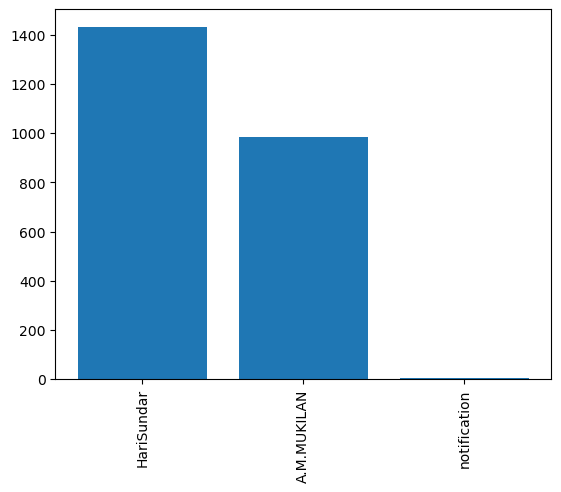

In [35]:
plt.bar(name,count)
plt.xticks(rotation = 'vertical')
plt.show()

In [36]:
df_percent = round((df['user'].value_counts() / df.shape[0]) * 100, 2).reset_index()
df_percent.columns = ['name', 'percent']

In [37]:
df_percent

,name,percent
0,HariSundar,59.24
1,A.M.MUKILAN,40.68
2,notification,0.08


In [38]:
temp =df[df['user']!='notification']
temp[temp['message'] != '<Media omitted>\n']

,date,user,message,year,month,day,hour,minute
2,2023-09-06 17:17:00,A.M.MUKILAN,Hi da I am mukilan from AIML Batch A Can you s...,2023,September,6,17,17
3,2023-09-06 17:57:00,HariSundar,yeh bro just 2 mins,2023,September,6,17,57
4,2023-09-06 17:58:00,HariSundar,why didn't you come to clg today??,2023,September,6,17,58
5,2023-09-06 17:58:00,A.M.MUKILAN,K thanks bro,2023,September,6,17,58
6,2023-09-06 17:58:00,HariSundar,Bunk 👀,2023,September,6,17,58
...,...,...,...,...,...,...,...,...
2414,2025-04-25 20:16:00,A.M.MUKILAN,😅,2025,April,25,20,16
2415,2025-04-25 23:04:00,HariSundar,https://www.youtube.com/shorts/4WI9Yu1mQ1I,2025,April,25,23,4
2416,2025-04-26 13:09:00,HariSundar,https://youtube.com/shorts/ehvwsoK9R7o?si=Y-AH...,2025,April,26,13,9
2417,2025-04-26 19:19:00,HariSundar,https://youtube.com/shorts/FBwV4kPErew?si=tP8K...,2025,April,26,19,19


In [39]:
with open('stopwords.txt', 'r', encoding='utf-8') as f:
    stop_words = f.read().splitlines()

print(stop_words)


['the', 'is', 'in', 'and', 'to', 'a', 'of', 'for', 'on', 'it', 'this', 'that', 'at', 'by', 'with', 'an', 'be', 'as', 'from', 'was', 'are', 'or', 'but', 'if', 'then', 'else', 'not', 'no', 'yes', 'about', 'so', 'up', 'out', 'what', 'when', 'where', 'who', 'which', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'only', 'own', 'same', 'than', 'too', 'very', 'can', 'will', 'just', 'don', 'should', 'now', 'there', 'their', 'your', 'you', 'me', 'we', 'they', 'he', 'she', 'him', 'her', 'my', 'our', 'its', 'been', 'did', 'has', 'have', 'having', 'over', 'under', 'again', 'also', 'whoever', 'whatever', 'however', 'before', 'after', 'during', 'while', 'because', 'although', 'though', 'into', 'onto', 'off', 'between', 'among', 'through', 'without', 'within', 'across', 'behind', 'beside', 'towards', 'upon', 'below', 'above', 'since', 'until', 'whether', 'whom', 'whose', 'shall', 'could', 'would', 'might', 'must', 'shouldn', 'couldn', 'wouldn', 'isn', 'wasn', 'w

In [40]:
words = []

for message in df['message']:
    message = message.lower()  # convert message to lowercase
    for word in message.split():
        if word not in stop_words:
            words.append(word)


In [41]:
words 

for message in df['message']:
    print(message.split())

['Messages', 'and', 'calls', 'are', 'end-to-end', 'encrypted.', 'Only', 'people', 'in', 'this', 'chat', 'can', 'read,', 'listen', 'to,', 'or', 'share', 'them.', 'Learn', 'more.']
['Messages', 'and', 'calls', 'are', 'end-to-end', 'encrypted.', 'Only', 'people', 'in', 'this', 'chat', 'can', 'read,', 'listen', 'to,', 'or', 'share', 'them.', 'Learn', 'more.']
['Hi', 'da', 'I', 'am', 'mukilan', 'from', 'AIML', 'Batch', 'A', 'Can', 'you', 'send', 'me', 'the', 'notes', 'taken', 'today']
['yeh', 'bro', 'just', '2', 'mins']
['why', "didn't", 'you', 'come', 'to', 'clg', 'today??']
['K', 'thanks', 'bro']
['Bunk', '👀']
['??']
['Health', 'issues', 'bro']
['ohh', 'okay', 'bro']
['take', 'care', 'buddy']
['how', 'are', 'you', 'now?']
['Illa', 'bro']
['fine??']
['K', 'bro']
['okay', 'okay', '😂']
['Fine', 'bro']
['I', 'will', 'just', 'send', 'you', 'after', 'few', 'mins', '👍']
['K', 'bro', 'No', 'problem']
['Okay', 'brother', '1st', 'period', 'programming', 'in', 'c', 'Sir', 'just', 'introduced', 'to',

In [42]:
from collections import Counter
pd.DataFrame(Counter(words).most_common(20))

,0,1
0,<media,287
1,omitted>,287
2,i,207
3,=,146
4,ya,120
5,},110
6,daa,108
7,{,99
8,u,98
9,sure,69


In [43]:
!pip install emoji


[notice] A new release of pip is available: 25.0 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
import emoji

In [48]:
import emoji

emojis = []
# Iterate through each message in the 'message' column of the DataFrame
for message in df['message']:
    # Check each character in the message if it's an emoji
    emojis.extend([c for c in message if emoji.is_emoji(c)])

# Output the list of extracted emojis
print(emojis)


['👀', '😂', '👍', '👍', '😅', '😅', '👍', '👍', '👍', '😅', '😅', '😜', '😁', '👍', '👍', '👍', '👍', '😂', '👍', '🏼', '🌃', '😴', '👋', '👋', '😅', '🧐', '🧐', '🌝', '🤡', '😂', '👍', '🏼', '🫠', '🫠', '👍', '🏼', '👍', '🏼', '👍', '🏼', '☠', '🫠', '🙂', '✨', '😭', '✨', '😭', '👍', '🙏', '🫂', '🫂', '🫂', '😂', '😂', '😂', '🙏', '🙏', '🥲', '☠', '🙂', '↔', '🥲', '😉', '👍', '👍', '✨', '😇', '✨', '👍', '👍', '👍', '🌟', '🌟', '🙏', '🙏', '🙏', '❤', '🤧', '☠', '😂', '🗿', '🗿', '🙏', '✨', '🥲', '🥲', '☠', '🗿', '🗿', '🗿', '🗿', '🗿', '✌', '✌', '🏆', '🗿', '🗿', '🗿', '😍', '🫂', '🫂', '❤', '💐', '💐', '💐', '💐', '🥰', '🥰', '😂', '🫡', '🙏', '🙏', '🙏', '😂', '😶', '🗿', '🗿', '😂', '☠', '☠', '😂', '🤔', '😶', '☠', '☠', '☠', '💀', '💀', '☠', '☠', '🫠', '🫠', '🫠', '🫠', '🫠', '🫠', '😂', '🥲', '🥲', '☠', '☠', '😌', '👋', '👋', '🙏', '🙏', '✌', '🫠', '🫠', '🎊', '🎊', '🎆', '🎆', '🔥', '🔥', '🔥', '🔥', '🎊', '😇', '😂', '😅', '😂', '😭', '🙏', '✌', '🫂', '😔', '🥲', '✌', '🔥', '🔥', '🔥', '🔥', '😤', '😤', '😤', '😤', '🗿', '🗿', '🗿', '🗿', '🗿', '🗿', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '😤', '😤', '😤', '😤', '😋', '😅', '😅', '🙏', '🙏', '🙏', '😅',

In [50]:
pd.DataFrame(Counter(emojis).most_common(len(Counter(emojis))))

,0,1
0,🙏,58
1,🔥,49
2,😂,48
3,😭,43
4,👍,23
...,...,...
61,🙇,1
62,♂,1
63,🙌,1
64,👇,1


In [58]:
df['month_num'] = df['date'].dt.month

In [60]:
timeline = df.groupby(['year','month_num','month']).count()['message'].reset_index()

In [62]:
timeline

,year,month_num,month,message
0,2023,9,September,163
1,2023,10,October,20
2,2023,11,November,136
3,2023,12,December,31
4,2024,1,January,5
5,2024,2,February,26
6,2024,3,March,59
7,2024,4,April,113
8,2024,5,May,136
9,2024,6,June,120


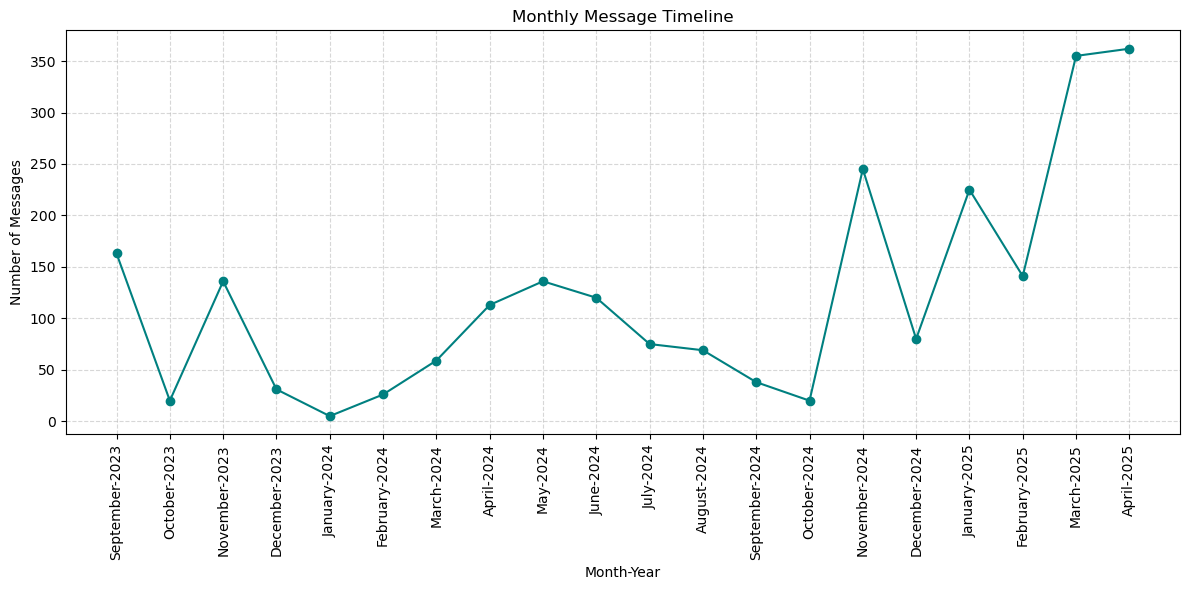

In [74]:
# Ensure timeline has 'month', 'year', and 'message' columns
timeline['time'] = timeline['month'].astype(str) + '-' + timeline['year'].astype(str)

plt.figure(figsize=(12, 6))
plt.plot(timeline['time'], timeline['message'], marker='o', color='teal')
plt.xticks(rotation='vertical')
plt.xlabel("Month-Year")
plt.ylabel("Number of Messages")
plt.title("Monthly Message Timeline")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [76]:
df['only_date'] = df['date'].dt.date

In [78]:
daily_timeline = df.groupby('only_date').count()['message'].reset_index()

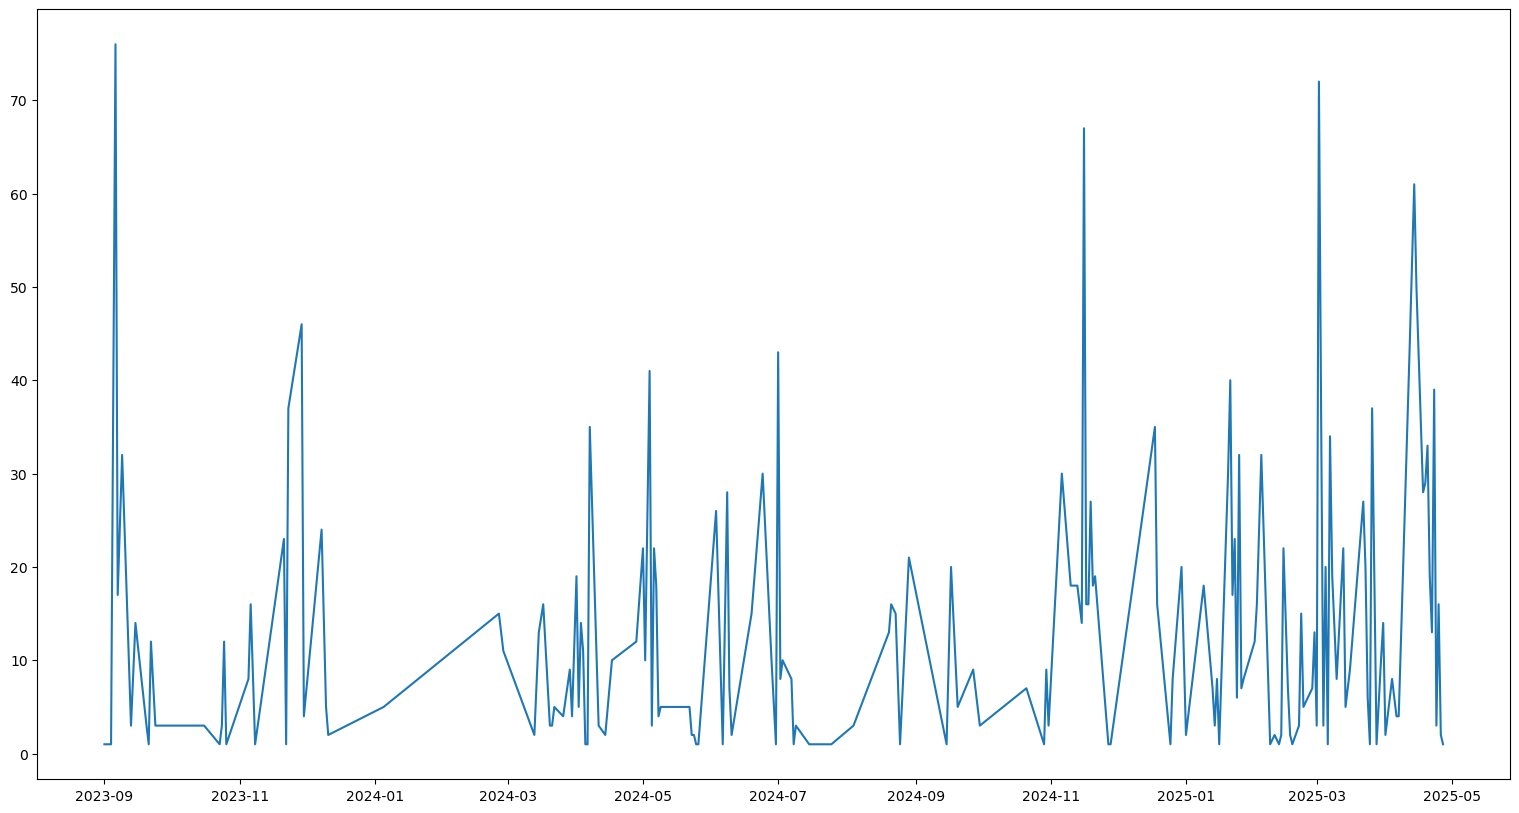

In [82]:
plt.figure(figsize=(19,10))
plt.plot(daily_timeline['only_date'],daily_timeline['message'])

In [86]:
df['day_name']=df['date'].dt.day_name()

In [88]:
df['day_name'].value_counts()

day_name
Wednesday    490
Monday       425
Saturday     365
Sunday       347
Friday       275
Tuesday      270
Thursday     247
Name: count, dtype: int64

period
Evening      1417
Afternoon     652
Morning       341
Night           9
Name: count, dtype: int64


C:\Users\Mukil\AppData\Local\Temp\ipykernel_2028\2917126964.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(index='day_name', columns='period', values='message', aggfunc='count')


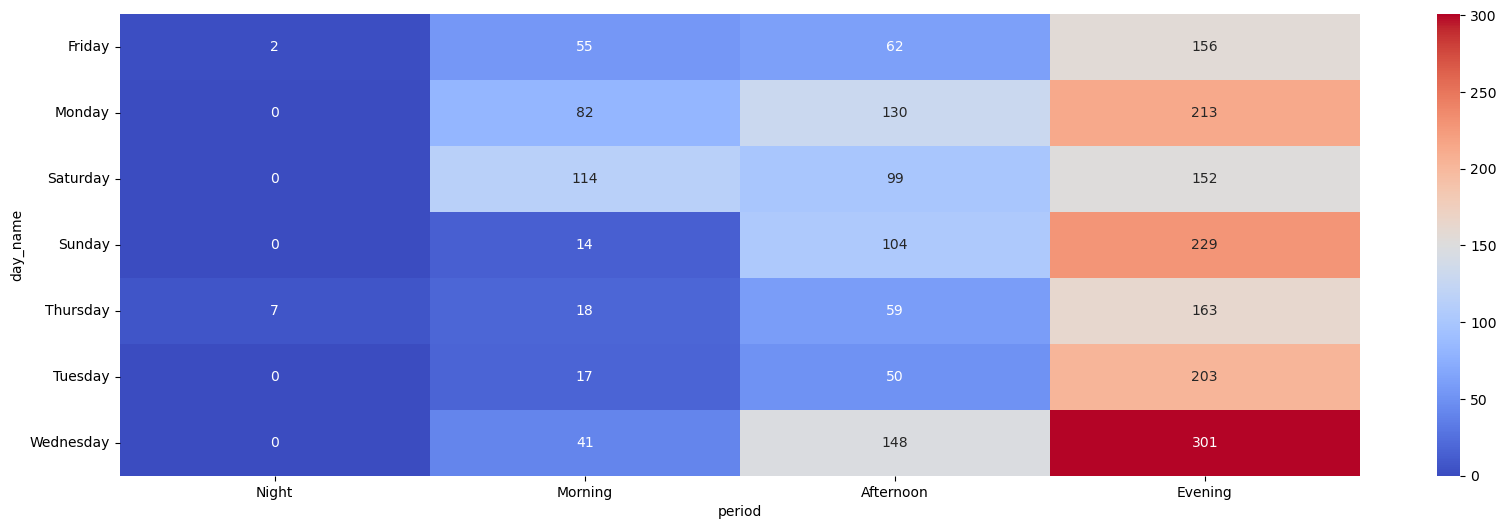

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame (replace this with your actual DataFrame)
# df = pd.read_csv('your_file.csv')  # Assuming you load your data this way

# Creating a 'period' column based on 'hour'
df['period'] = pd.cut(df['hour'], bins=[0, 6, 12, 18, 24], labels=['Night', 'Morning', 'Afternoon', 'Evening'], right=False)

# Checking if the 'period' column was created successfully
print(df['period'].value_counts())

# Create a pivot table for the heatmap
plt.figure(figsize=(20, 6))

# Pivot table for the heatmap (using 'day_name' as index and 'period' as columns)
heatmap_data = df.pivot_table(index='day_name', columns='period', values='message', aggfunc='count')

# Plot the heatmap
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt="d")

# Rotate y-axis labels for better readability
plt.yticks(rotation='horizontal')

# Display the plot
plt.show()


In [98]:

df.pivot_table(index='day_name', columns='period', values='message', aggfunc='count')

C:\Users\Mukil\AppData\Local\Temp\ipykernel_2028\1898547448.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='day_name', columns='period', values='message', aggfunc='count')


period,Night,Morning,Afternoon,Evening
day_name,,,,
Friday,2,55,62,156
Monday,0,82,130,213
Saturday,0,114,99,152
Sunday,0,14,104,229
Thursday,7,18,59,163
Tuesday,0,17,50,203
Wednesday,0,41,148,301
